# Mixture of Experts (MoE)

A standard transformer uses one FFN per layer. Every token goes through the same
weights. **Mixture of Experts** replaces this single FFN with N **expert** FFNs
and a **router** that picks which experts each token uses.

This lets you scale model parameters **without scaling compute** — each token
only activates a small fraction of the total parameters.

| Model | Total params | Active params per token | Experts |
|-------|-------------|------------------------|---------|
| LLaMA 3 70B | 70B | 70B (dense) | 1 (standard FFN) |
| Mixtral 8x7B | 47B | 13B | 8 experts, top-2 routing |
| DeepSeek-V2 | 236B | 21B | 160 experts, top-6 routing |
| GPT-4 (rumored) | ~1.8T | ~280B | 16 experts, top-2 routing |

This notebook covers:
1. **Why MoE?** — the scaling problem and how sparse experts solve it
2. **The Router** — how tokens choose their experts
3. **Top-k expert selection** — why we use 2 experts, not 1 or all
4. **Load balancing** — preventing expert collapse
5. **Full MoE layer** — from scratch, with visualizations
6. **Comparison** — dense vs MoE on our tiny model

### References
- [Mixtral of Experts](https://arxiv.org/abs/2401.04088) (Jiang et al., 2024)
- [Switch Transformers: Scaling to Trillion Parameter Models](https://arxiv.org/abs/2101.03961) (Fedus et al., 2022)
- [Outrageously Large Neural Networks: The Sparsely-Gated Mixture-of-Experts Layer](https://arxiv.org/abs/1701.06538) (Shazeer et al., 2017)
- [docs/PAPERS.md](../../docs/PAPERS.md)

> 📺 **Video companion:** [A Visual Guide to Mixture of Experts (Maarten Grootendorst)](https://www.youtube.com/watch?v=sOPDGQjFcuM) covers the routing, expert capacity, and load-balancing ideas this notebook implements — more in [Videos](../../docs/VIDEOS.md).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/01_transformer_internals/02_mixture_of_experts.ipynb)

In [1]:
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

In [2]:
import sys
sys.path.insert(0, '../src')

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import math

from ai_playground.models.layers import SwiGLU

torch.manual_seed(42)
device = 'cpu'

## 1. Why MoE? The Scaling Problem

Making a model smarter means more parameters. But more parameters = more compute
per token = slower inference.

**MoE breaks this tradeoff**: you can have 8× more parameters while only using
~2× more compute per token (by activating 2 out of 8 experts).

The key insight: **not all knowledge is needed for every token.** A math token
needs different weights than a poetry token. Experts can specialize.

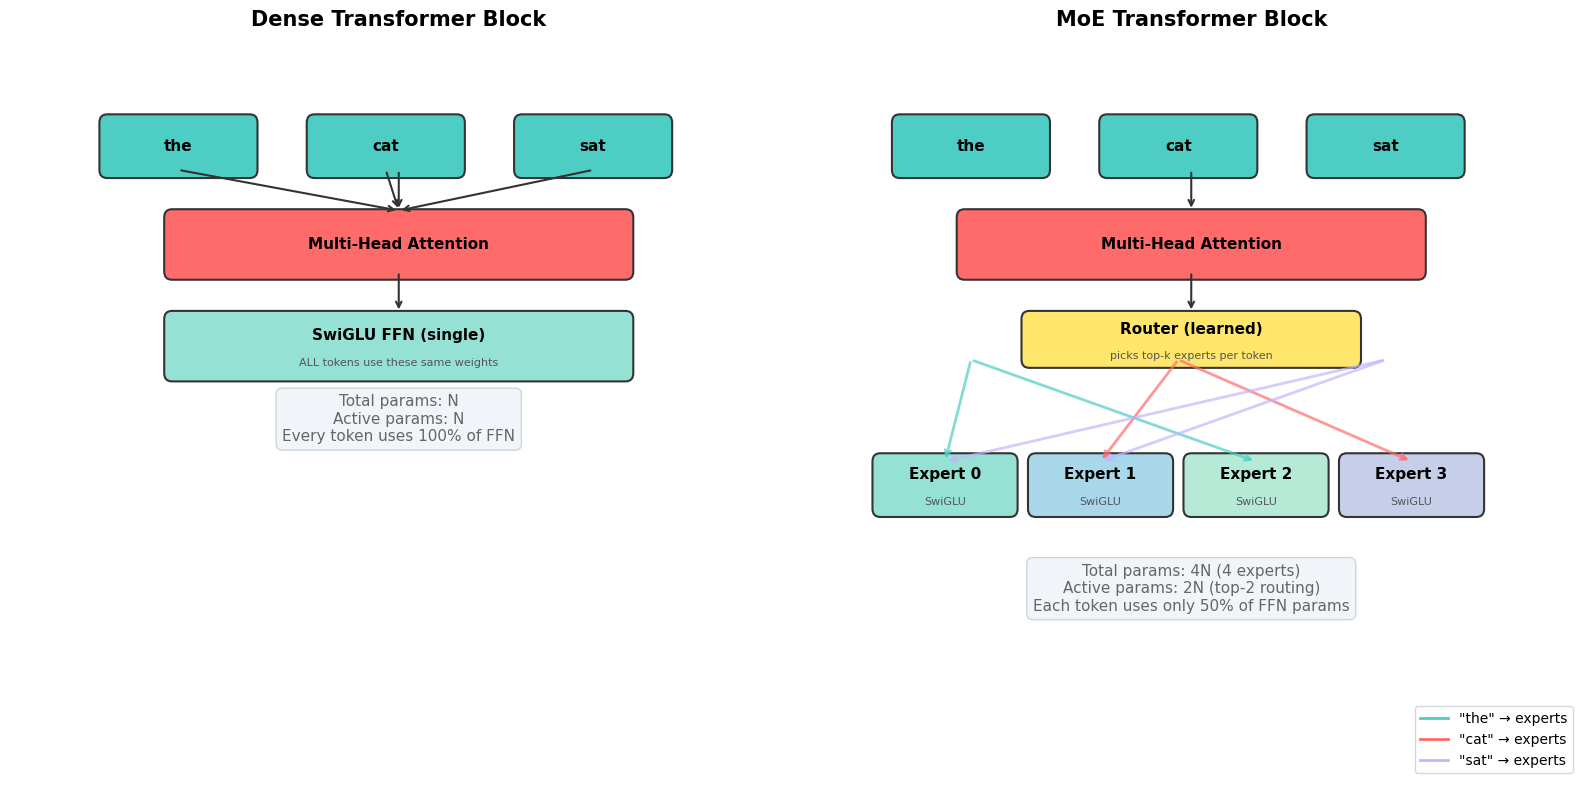

Left: Dense model — every token goes through the SAME FFN.
Right: MoE model — router sends each token to its TOP-2 experts.
4x parameters, but only 2x compute (since each token uses 2 of 4 experts).


In [3]:
# Visualize: Dense vs MoE architecture
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- Left: Dense FFN ---
ax = ax1
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 10)
ax.axis('off')
ax.set_title('Dense Transformer Block', fontsize=15, fontweight='bold')

def box(ax, x, y, w, h, label, color, sublabel=None, fontsize=11):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.12',
                                    facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + (0.15 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize, fontweight='bold')
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.25, sublabel,
                ha='center', va='center', fontsize=8, color='#555')

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

# Input tokens
for i, tok in enumerate(['the', 'cat', 'sat']):
    box(ax, i*3.2 + 0.5, 8, 2.2, 0.7, tok, '#4ECDC4')

# Attention
arrow(ax, 5, 8, 5, 7.4)
box(ax, 1.5, 6.5, 7, 0.8, 'Multi-Head Attention', '#FF6B6B')

# Single FFN — all tokens go through same weights
arrow(ax, 5, 6.5, 5, 5.9)
box(ax, 1.5, 5, 7, 0.8, 'SwiGLU FFN (single)', '#95E1D3', 'ALL tokens use these same weights')

# Arrows from each token to FFN
for i in range(3):
    arrow(ax, i*3.2 + 1.6, 8, 5, 7.4)

ax.text(5, 4.0, f'Total params: N\nActive params: N\nEvery token uses 100% of FFN',
        ha='center', fontsize=11, color='#666',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F1F5F9', edgecolor='#CBD5E1'))

# --- Right: MoE ---
ax = ax2
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 10)
ax.axis('off')
ax.set_title('MoE Transformer Block', fontsize=15, fontweight='bold')

# Input tokens
for i, tok in enumerate(['the', 'cat', 'sat']):
    box(ax, i*3.2 + 0.5, 8, 2.2, 0.7, tok, '#4ECDC4')

# Attention
arrow(ax, 5, 8, 5, 7.4)
box(ax, 1.5, 6.5, 7, 0.8, 'Multi-Head Attention', '#FF6B6B')

# Router
arrow(ax, 5, 6.5, 5, 5.9)
box(ax, 2.5, 5.2, 5, 0.6, 'Router (learned)', '#FFE66D', 'picks top-k experts per token')

# Expert FFNs
expert_colors = ['#95E1D3', '#A8D8EA', '#B5EAD7', '#C7CEEA', '#E2F0CB', '#FFDAC1', '#FFB7B2', '#FF9AA2']
for i in range(4):
    x = i * 2.4 + 0.2
    box(ax, x, 3.0, 2.0, 0.7, f'Expert {i}', expert_colors[i], 'SwiGLU')

# Routing arrows — each token goes to 2 experts
routing = [(0, [0, 2]), (1, [1, 3]), (2, [0, 1])]  # token → expert indices
route_colors = ['#4ECDC4', '#FF6B6B', '#C4B5FD']
for tok_i, (_, expert_ids) in enumerate(routing):
    for exp_i in expert_ids:
        x_start = tok_i * 3.2 + 1.6
        x_end = exp_i * 2.4 + 1.2
        ax.annotate('', xy=(x_end, 3.7), xytext=(x_start, 5.2),
                    arrowprops=dict(arrowstyle='->', color=route_colors[tok_i],
                                    lw=2, alpha=0.7))

ax.text(5, 1.5, f'Total params: 4N (4 experts)\nActive params: 2N (top-2 routing)\nEach token uses only 50% of FFN params',
        ha='center', fontsize=11, color='#666',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F1F5F9', edgecolor='#CBD5E1'))

# Legend
for i, (tok, color) in enumerate(zip(['the', 'cat', 'sat'], route_colors)):
    ax.plot([], [], color=color, linewidth=2, label=f'"{tok}" → experts')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print('Left: Dense model — every token goes through the SAME FFN.')
print('Right: MoE model — router sends each token to its TOP-2 experts.')
print('4x parameters, but only 2x compute (since each token uses 2 of 4 experts).')

## 2. The Router

The router is a simple linear layer that scores each expert for each token:

```
router_scores = x @ W_router      # (batch, seq, n_experts)
router_probs  = softmax(scores)    # probability per expert
top_k_experts = topk(probs, k=2)   # pick the best 2
```

The router is **learned** — it trains alongside the model. Over time, it learns
which expert patterns match which token patterns.

[Switch Transformers](https://arxiv.org/abs/2101.03961) showed that even k=1
(single expert per token) works well, but k=2 is more common in practice
(Mixtral, DeepSeek) for better quality.

In [4]:
# Build a router from scratch
class Router(nn.Module):
    """Token-to-expert routing via learned linear projection.
    
    Each token gets a score for each expert. We pick the top-k.
    
    References:
    - Switch Transformers: https://arxiv.org/abs/2101.03961
    - Mixtral: https://arxiv.org/abs/2401.04088
    """
    def __init__(self, dim: int, n_experts: int, top_k: int = 2):
        super().__init__()
        self.top_k = top_k
        self.gate = nn.Linear(dim, n_experts, bias=False)
    
    def forward(self, x: torch.Tensor):
        # x: (batch, seq, dim)
        scores = self.gate(x)                    # (batch, seq, n_experts)
        probs = F.softmax(scores, dim=-1)        # normalize to probabilities
        
        # Select top-k experts per token
        top_k_probs, top_k_indices = probs.topk(self.top_k, dim=-1)
        
        # Renormalize selected expert weights to sum to 1
        top_k_probs = top_k_probs / top_k_probs.sum(dim=-1, keepdim=True)
        
        return top_k_probs, top_k_indices, probs

# Demo
dim = 32
n_experts = 8
router = Router(dim, n_experts, top_k=2)

# Simulate 6 tokens
tokens = torch.randn(1, 6, dim)
top_k_probs, top_k_indices, all_probs = router(tokens)

print(f'Router: {dim}-dim input → {n_experts} expert scores → top-2 selection\n')
print(f'All expert probabilities (6 tokens × 8 experts):')
for i in range(6):
    probs_str = ' '.join(f'{p:.2f}' for p in all_probs[0, i].tolist())
    print(f'  Token {i}: [{probs_str}]')

print(f'\nSelected experts (top-2 per token):')
for i in range(6):
    experts = top_k_indices[0, i].tolist()
    weights = top_k_probs[0, i].tolist()
    print(f'  Token {i}: expert {experts[0]} ({weights[0]:.0%}) + expert {experts[1]} ({weights[1]:.0%})')

Router: 32-dim input → 8 expert scores → top-2 selection

All expert probabilities (6 tokens × 8 experts):
  Token 0: [0.06 0.12 0.08 0.06 0.10 0.22 0.23 0.13]
  Token 1: [0.22 0.15 0.09 0.23 0.09 0.10 0.04 0.08]
  Token 2: [0.05 0.06 0.24 0.15 0.09 0.22 0.06 0.12]
  Token 3: [0.09 0.03 0.27 0.08 0.05 0.13 0.14 0.21]
  Token 4: [0.10 0.17 0.09 0.14 0.15 0.18 0.12 0.05]
  Token 5: [0.12 0.12 0.07 0.10 0.33 0.07 0.15 0.04]

Selected experts (top-2 per token):
  Token 0: expert 6 (52%) + expert 5 (48%)
  Token 1: expert 3 (51%) + expert 0 (49%)
  Token 2: expert 2 (52%) + expert 5 (48%)
  Token 3: expert 2 (56%) + expert 7 (44%)
  Token 4: expert 5 (51%) + expert 1 (49%)
  Token 5: expert 4 (69%) + expert 6 (31%)


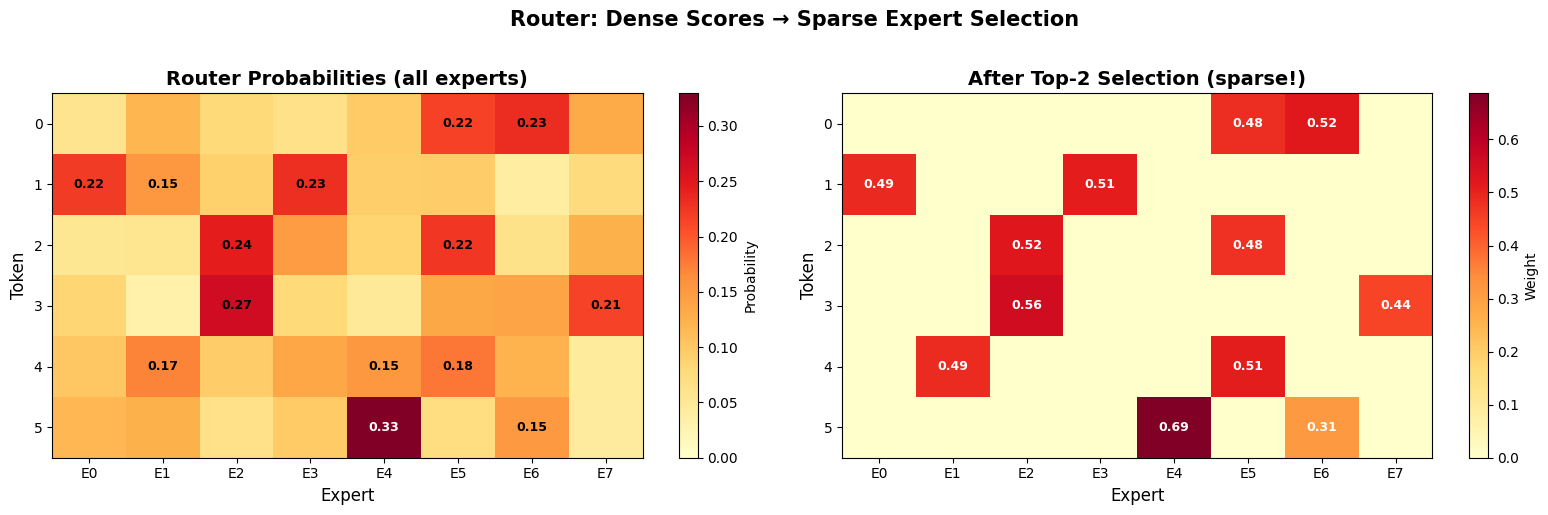

Each token uses 2/8 = 25% of experts.
This is the "sparsity" that makes MoE efficient.


In [5]:
# Visualize router probabilities as a heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: full probability distribution
im = ax1.imshow(all_probs[0].detach().numpy(), cmap='YlOrRd', aspect='auto', vmin=0)
ax1.set_xlabel('Expert', fontsize=12)
ax1.set_ylabel('Token', fontsize=12)
ax1.set_xticks(range(n_experts))
ax1.set_xticklabels([f'E{i}' for i in range(n_experts)])
ax1.set_title('Router Probabilities (all experts)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax1, label='Probability')

# Annotate values
for i in range(6):
    for j in range(n_experts):
        val = all_probs[0, i, j].item()
        if val > 0.15:
            ax1.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white' if val > 0.3 else 'black')

# Right: selected experts only (sparse)
selected = torch.zeros(6, n_experts)
for i in range(6):
    for k in range(2):
        exp_idx = top_k_indices[0, i, k].item()
        selected[i, exp_idx] = top_k_probs[0, i, k].item()

im2 = ax2.imshow(selected.numpy(), cmap='YlOrRd', aspect='auto', vmin=0)
ax2.set_xlabel('Expert', fontsize=12)
ax2.set_ylabel('Token', fontsize=12)
ax2.set_xticks(range(n_experts))
ax2.set_xticklabels([f'E{i}' for i in range(n_experts)])
ax2.set_title('After Top-2 Selection (sparse!)', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='Weight')

for i in range(6):
    for j in range(n_experts):
        val = selected[i, j].item()
        if val > 0:
            ax2.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white' if val > 0.3 else 'black')

plt.suptitle('Router: Dense Scores → Sparse Expert Selection', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Each token uses {2}/{n_experts} = {2/n_experts:.0%} of experts.')
print(f'This is the "sparsity" that makes MoE efficient.')

## 3. Full MoE Layer

Let's build a complete MoE layer that replaces the standard FFN.
Each expert is a SwiGLU FFN (same as in our dense model), but
there are N of them, and each token only uses top-k.

In [6]:
class MoELayer(nn.Module):
    """Mixture of Experts layer — replaces the dense FFN.
    
    Each expert is an independent SwiGLU FFN. The router picks
    top-k experts per token. Output = weighted sum of selected experts.
    
    References:
    - Mixtral: https://arxiv.org/abs/2401.04088
    - Switch Transformers: https://arxiv.org/abs/2101.03961
    - Original MoE: https://arxiv.org/abs/1701.06538
    """
    def __init__(self, dim: int, hidden_dim: int, n_experts: int = 8, top_k: int = 2):
        super().__init__()
        self.n_experts = n_experts
        self.top_k = top_k
        self.router = Router(dim, n_experts, top_k)
        
        # N independent expert FFNs
        self.experts = nn.ModuleList([
            SwiGLU(dim, hidden_dim) for _ in range(n_experts)
        ])
    
    def forward(self, x: torch.Tensor):
        """Forward pass with sparse expert routing.
        
        For each token:
        1. Router picks top-k experts and their weights
        2. Run token through selected experts only
        3. Output = weighted sum of expert outputs
        """
        batch, seq_len, dim = x.shape
        
        # Route: which experts for each token?
        top_k_probs, top_k_indices, all_probs = self.router(x)
        # top_k_probs: (batch, seq, top_k)
        # top_k_indices: (batch, seq, top_k)
        
        # Process each token through its selected experts
        # (In production, this is done with scatter/gather for GPU efficiency.
        #  Here we loop for clarity.)
        output = torch.zeros_like(x)
        
        for b in range(batch):
            for t in range(seq_len):
                token = x[b, t].unsqueeze(0)  # (1, dim)
                
                for k in range(self.top_k):
                    expert_idx = top_k_indices[b, t, k].item()
                    weight = top_k_probs[b, t, k]
                    
                    # Run through this expert and weight by router score
                    expert_output = self.experts[expert_idx](token.unsqueeze(0))
                    output[b, t] += weight * expert_output.squeeze(0).squeeze(0)
        
        return output, all_probs

# Build and test
dim = 32
hidden_dim = 64
n_experts = 8
top_k = 2

moe = MoELayer(dim, hidden_dim, n_experts, top_k)
x = torch.randn(1, 6, dim)

with torch.no_grad():
    out, probs = moe(x)

# Count parameters
dense_params = sum(p.numel() for p in SwiGLU(dim, hidden_dim).parameters())
moe_params = sum(p.numel() for p in moe.parameters())

print(f'MoE Layer: {n_experts} experts, top-{top_k} routing')
print(f'  Input:  {list(x.shape)}')
print(f'  Output: {list(out.shape)}  (same shape — drop-in FFN replacement)\n')
print(f'Parameter comparison:')
print(f'  Dense FFN:     {dense_params:>8,} params (1 expert)')
print(f'  MoE layer:     {moe_params:>8,} params ({n_experts} experts + router)')
print(f'  Ratio:         {moe_params/dense_params:.1f}x more params')
print(f'  Active params: {dense_params * top_k:>8,} per token ({top_k} experts)')
print(f'  Efficiency:    {top_k}/{n_experts} = {top_k/n_experts:.0%} of params used per token')

MoE Layer: 8 experts, top-2 routing
  Input:  [1, 6, 32]
  Output: [1, 6, 32]  (same shape — drop-in FFN replacement)

Parameter comparison:
  Dense FFN:        6,144 params (1 expert)
  MoE layer:       49,408 params (8 experts + router)
  Ratio:         8.0x more params
  Active params:   12,288 per token (2 experts)
  Efficiency:    2/8 = 25% of params used per token


## 4. Load Balancing: The Expert Collapse Problem

A naive router often learns to send all tokens to the same 1-2 experts,
leaving the rest unused. This is called **expert collapse** — the model
effectively shrinks to a dense model.

**Auxiliary load balancing loss** fixes this by penalizing uneven expert usage:

```
balance_loss = n_experts × mean(fraction_per_expert) × mean(prob_per_expert)
```

This encourages the router to spread tokens across experts.
[Switch Transformers](https://arxiv.org/abs/2101.03961) introduced this as
a lightweight add-on to the main cross-entropy loss (weighted by ~0.01).

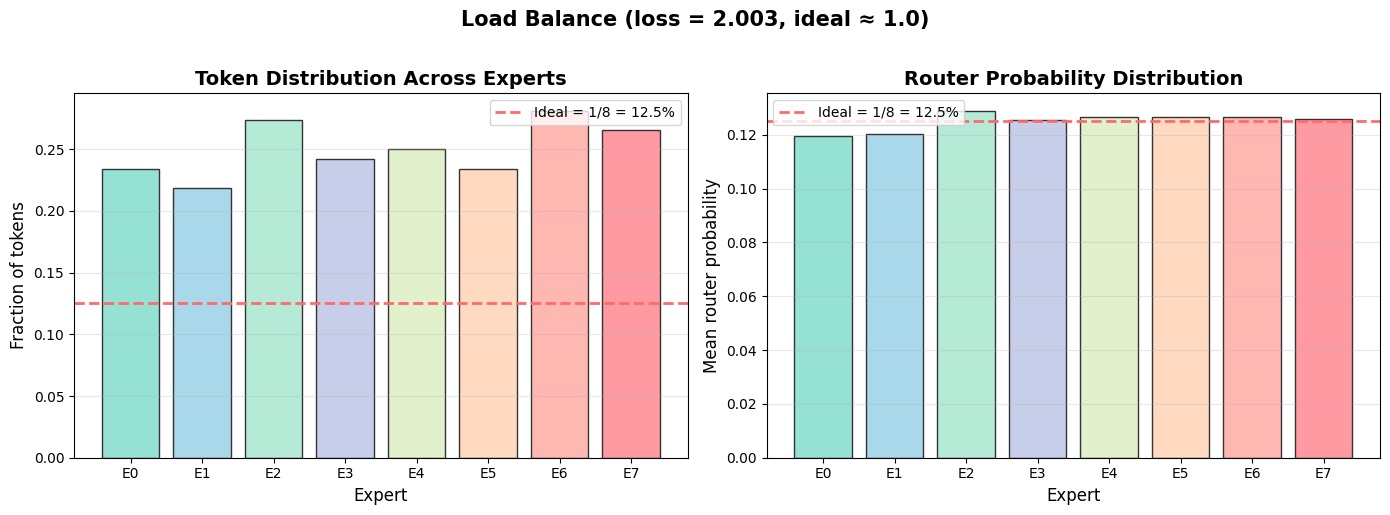

Load balance loss: 2.003
Ideal (uniform): 1.0
Collapsed (all to 1 expert): 8.0

The loss penalizes deviation from uniform — higher = more imbalanced.


In [7]:
def compute_load_balance_loss(router_probs, top_k_indices, n_experts):
    """Auxiliary loss to prevent expert collapse.
    
    Encourages equal token distribution across experts.
    From Switch Transformers (https://arxiv.org/abs/2101.03961) §3.1.
    """
    # router_probs: (batch, seq, n_experts) — full probability distribution
    # top_k_indices: (batch, seq, top_k) — selected expert indices
    
    batch, seq_len = router_probs.shape[:2]
    total_tokens = batch * seq_len
    
    # Fraction of tokens assigned to each expert
    # (count how many tokens selected each expert)
    expert_mask = F.one_hot(top_k_indices, n_experts).sum(dim=2)  # (batch, seq, n_experts)
    fraction_per_expert = expert_mask.float().sum(dim=(0, 1)) / total_tokens
    
    # Average router probability per expert
    mean_prob_per_expert = router_probs.mean(dim=(0, 1))
    
    # Loss = n_experts * dot(fraction, mean_prob)
    # Minimized when both are uniform (1/n_experts each)
    balance_loss = n_experts * (fraction_per_expert * mean_prob_per_expert).sum()
    
    return balance_loss, fraction_per_expert, mean_prob_per_expert

# Visualize expert load distribution
torch.manual_seed(42)
moe_viz = MoELayer(dim, hidden_dim, n_experts=8, top_k=2)
x_viz = torch.randn(4, 32, dim)  # 4 batches × 32 tokens = 128 tokens

with torch.no_grad():
    _, all_probs_viz = moe_viz(x_viz)
    _, top_k_idx_viz = all_probs_viz.topk(2, dim=-1)
    loss, frac, mean_p = compute_load_balance_loss(all_probs_viz, top_k_idx_viz, 8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: fraction of tokens per expert
colors_bar = [expert_colors[i] for i in range(8)]
ax1.bar(range(8), frac.numpy(), color=colors_bar, edgecolor='#333')
ax1.axhline(y=1/8, color='#FF6B6B', linestyle='--', linewidth=2, label=f'Ideal = 1/{8} = {1/8:.1%}')
ax1.set_xlabel('Expert', fontsize=12)
ax1.set_ylabel('Fraction of tokens', fontsize=12)
ax1.set_title('Token Distribution Across Experts', fontsize=14, fontweight='bold')
ax1.set_xticks(range(8))
ax1.set_xticklabels([f'E{i}' for i in range(8)])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Right: average router probability per expert
ax2.bar(range(8), mean_p.numpy(), color=colors_bar, edgecolor='#333')
ax2.axhline(y=1/8, color='#FF6B6B', linestyle='--', linewidth=2, label=f'Ideal = 1/{8} = {1/8:.1%}')
ax2.set_xlabel('Expert', fontsize=12)
ax2.set_ylabel('Mean router probability', fontsize=12)
ax2.set_title('Router Probability Distribution', fontsize=14, fontweight='bold')
ax2.set_xticks(range(8))
ax2.set_xticklabels([f'E{i}' for i in range(8)])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Load Balance (loss = {loss.item():.3f}, ideal ≈ 1.0)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Load balance loss: {loss.item():.3f}')
print(f'Ideal (uniform): 1.0')
print(f'Collapsed (all to 1 expert): {8:.1f}')
print(f'\nThe loss penalizes deviation from uniform — higher = more imbalanced.')

## 5. Train Dense vs MoE: Side by Side

Let's train two models on the same data:
- **Dense**: standard SwiGLU FFN (like our regular transformer)
- **MoE**: 4 expert FFNs with top-2 routing

Same total compute budget (the MoE model has more params but only activates 2 experts).

In [8]:
from ai_playground.models.layers import RMSNorm
from ai_playground.models.attention import GroupedQueryAttention
from ai_playground.models import TransformerConfig
from ai_playground.models.layers import precompute_rope_frequencies

class TransformerBlockDense(nn.Module):
    """Standard transformer block with dense FFN."""
    def __init__(self, config):
        super().__init__()
        self.attention = GroupedQueryAttention(config)
        self.ffn = SwiGLU(config.dim, config.ffn_hidden_dim)
        self.norm1 = RMSNorm(config.dim)
        self.norm2 = RMSNorm(config.dim)
    
    def forward(self, x, freqs_cis, mask=None):
        x = x + self.attention(self.norm1(x), freqs_cis, mask)
        x = x + self.ffn(self.norm2(x))
        return x, None  # None = no aux loss

class TransformerBlockMoE(nn.Module):
    """Transformer block with MoE FFN."""
    def __init__(self, config, n_experts=4, top_k=2):
        super().__init__()
        self.attention = GroupedQueryAttention(config)
        self.moe = MoELayer(config.dim, config.ffn_hidden_dim, n_experts, top_k)
        self.norm1 = RMSNorm(config.dim)
        self.norm2 = RMSNorm(config.dim)
        self.n_experts = n_experts
    
    def forward(self, x, freqs_cis, mask=None):
        x = x + self.attention(self.norm1(x), freqs_cis, mask)
        moe_out, router_probs = self.moe(self.norm2(x))
        x = x + moe_out
        
        # Compute aux load balance loss
        _, top_k_idx = router_probs.topk(self.moe.top_k, dim=-1)
        aux_loss, _, _ = compute_load_balance_loss(router_probs, top_k_idx, self.n_experts)
        return x, aux_loss

class TinyTransformer(nn.Module):
    """Minimal transformer for dense vs MoE comparison."""
    def __init__(self, config, block_cls, **block_kwargs):
        super().__init__()
        self.config = config
        self.embed = nn.Embedding(config.vocab_size, config.dim)
        self.layers = nn.ModuleList([block_cls(config, **block_kwargs) for _ in range(config.n_layers)])
        self.norm = RMSNorm(config.dim)
        self.output = nn.Linear(config.dim, config.vocab_size, bias=False)
        self.register_buffer('freqs_cis',
            precompute_rope_frequencies(config.head_dim, config.max_seq_len))
    
    def forward(self, tokens):
        h = self.embed(tokens)
        freqs = self.freqs_cis[:tokens.shape[1]]
        total_aux = 0.0
        for layer in self.layers:
            h, aux = layer(h, freqs)
            if aux is not None:
                total_aux = total_aux + aux
        h = self.norm(h)
        return self.output(h), total_aux

# Config
config = TransformerConfig(
    vocab_size=8, dim=32, n_layers=2, n_heads=4,
    n_kv_heads=2, max_seq_len=16, ffn_dim_multiplier=2.0,
)

# Build both
torch.manual_seed(42)
model_dense = TinyTransformer(config, TransformerBlockDense)
torch.manual_seed(42)
model_moe = TinyTransformer(config, TransformerBlockMoE, n_experts=4, top_k=2)

params_dense = sum(p.numel() for p in model_dense.parameters())
params_moe = sum(p.numel() for p in model_moe.parameters())

print(f'Dense model: {params_dense:>8,} params')
print(f'MoE model:   {params_moe:>8,} params ({params_moe/params_dense:.1f}x more)')
print(f'MoE active:  ~{params_dense + (params_moe - params_dense) * 2 // 4:,} per token (2 of 4 experts)')

Dense model:   19,104 params
MoE model:     56,224 params (2.9x more)
MoE active:  ~37,664 per token (2 of 4 experts)


Dense        | final loss: 0.2786


MoE (4×top2) | final loss: 0.2786


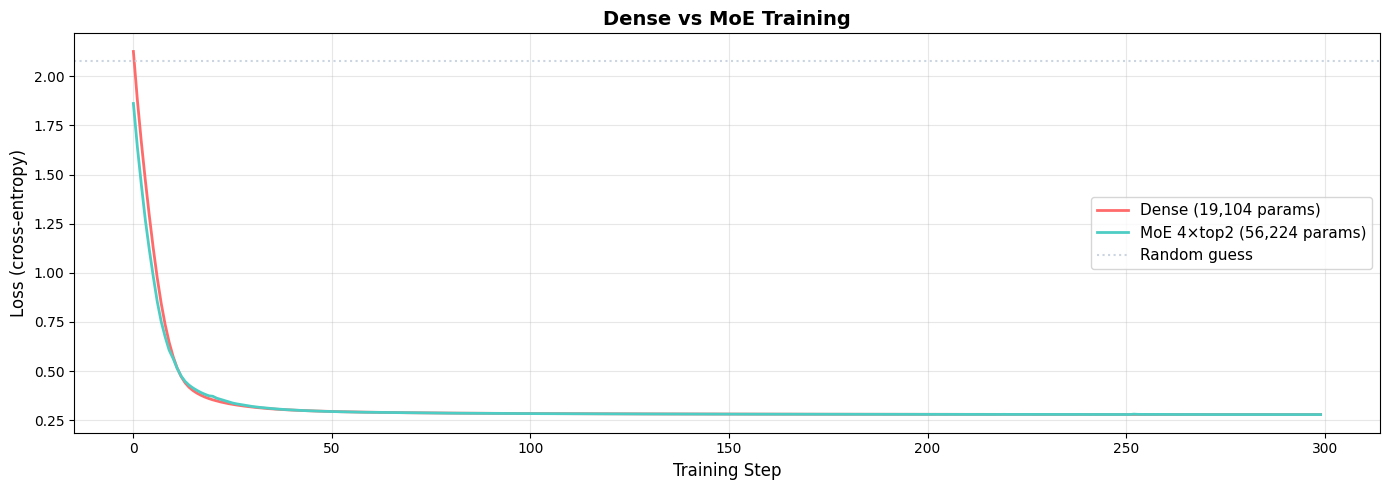


Note: On this tiny dataset, both converge quickly.
The MoE advantage shows at scale — more params without proportional compute.


In [9]:
# Training data
VOCAB = ['<pad>', 'the', 'cat', 'dog', 'sat', 'ran', 'on', 'mat']
tok2id = {t: i for i, t in enumerate(VOCAB)}
sentences = ['the cat sat on the mat', 'the dog ran on the mat',
             'the cat ran on the mat', 'the dog sat on the mat']
all_tok = [[tok2id[w] for w in s.split()] for s in sentences]
train_x = torch.tensor([t[:-1] for t in all_tok])
train_y = torch.tensor([t[1:] for t in all_tok])

def train_model(model, name, n_steps=300, aux_weight=0.01):
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
    losses = []
    model.train()
    for step in range(n_steps):
        logits, aux_loss = model(train_x)
        ce_loss = F.cross_entropy(logits.view(-1, 8), train_y.view(-1))
        loss = ce_loss + aux_weight * aux_loss if isinstance(aux_loss, torch.Tensor) else ce_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(ce_loss.item())
    
    print(f'{name:12s} | final loss: {losses[-1]:.4f}')
    return losses

losses_dense = train_model(model_dense, 'Dense')
losses_moe = train_model(model_moe, 'MoE (4×top2)')

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(losses_dense, label=f'Dense ({params_dense:,} params)', color='#FF6B6B', linewidth=2)
ax.plot(losses_moe, label=f'MoE 4×top2 ({params_moe:,} params)', color='#4ECDC4', linewidth=2)
ax.axhline(y=np.log(8), color='#CBD5E1', linestyle=':', label='Random guess')
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Loss (cross-entropy)', fontsize=12)
ax.set_title('Dense vs MoE Training', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nNote: On this tiny dataset, both converge quickly.')
print(f'The MoE advantage shows at scale — more params without proportional compute.')

## 6. Expert Specialization

Do the experts actually learn different things? Let's check which expert
gets selected for which tokens after training.

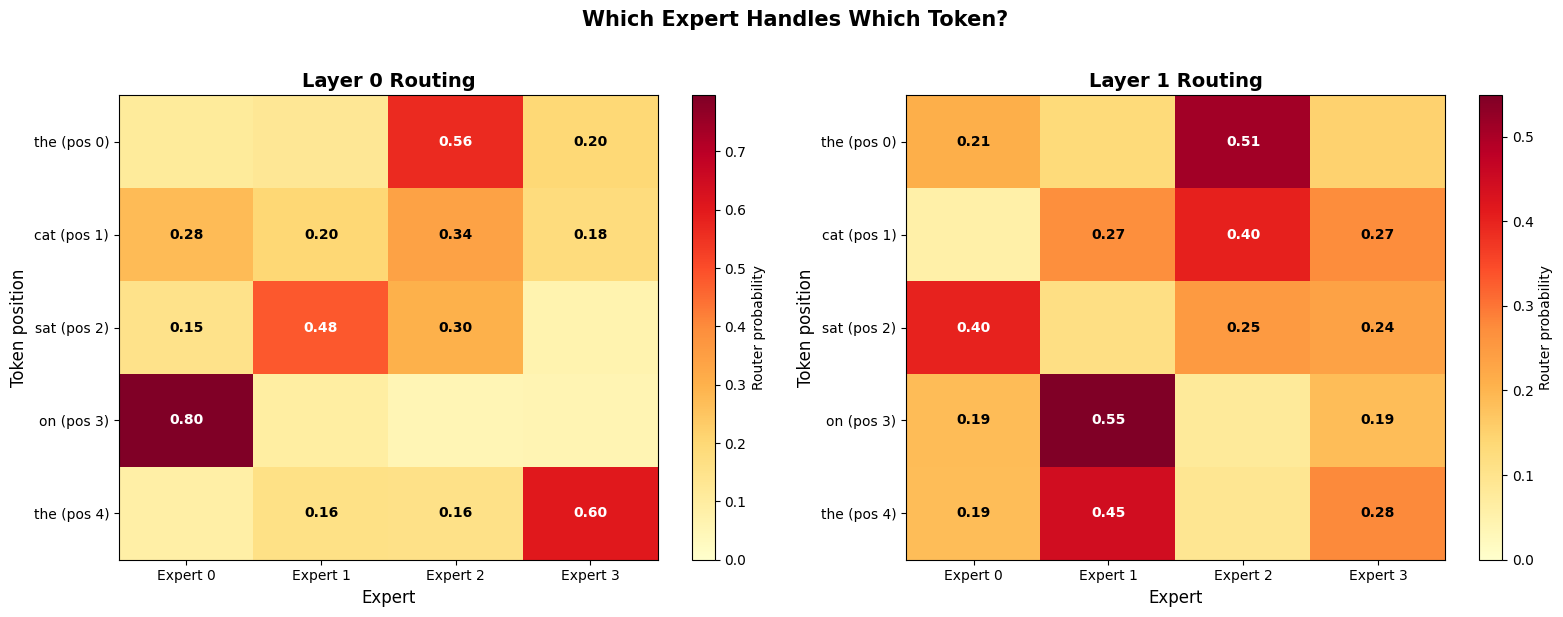

Different tokens may prefer different experts — this is specialization.
The router learned this without any supervision — just from the training signal.


In [10]:
# Analyze routing after training
model_moe.eval()
with torch.no_grad():
    _, _ = model_moe(train_x)  # warm up
    
    # Collect routing decisions
    h = model_moe.embed(train_x)
    freqs = model_moe.freqs_cis[:train_x.shape[1]]
    
    all_routing = []
    for layer_idx, layer in enumerate(model_moe.layers):
        h_normed = layer.norm1(h)
        h = h + layer.attention(h_normed, freqs)
        h_normed2 = layer.norm2(h)
        _, router_probs = layer.moe(h_normed2)
        all_routing.append(router_probs)
        moe_out, _ = layer.moe(h_normed2)
        h = h + moe_out

id2tok = {i: t for t, i in tok2id.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for layer_idx, (ax, probs) in enumerate(zip(axes, all_routing)):
    # Average routing across all 4 sentences
    avg_probs = probs.mean(dim=0)  # (seq_len=5, n_experts=4)
    
    im = ax.imshow(avg_probs.numpy(), cmap='YlOrRd', aspect='auto', vmin=0)
    ax.set_xlabel('Expert', fontsize=12)
    ax.set_ylabel('Token position', fontsize=12)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'Expert {i}' for i in range(4)])
    ax.set_yticks(range(5))
    
    # Label with actual token names (from first sentence)
    token_labels = [id2tok[train_x[0, i].item()] for i in range(5)]
    ax.set_yticklabels([f'{tok} (pos {i})' for i, tok in enumerate(token_labels)], fontsize=10)
    ax.set_title(f'Layer {layer_idx} Routing', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Router probability')
    
    # Annotate
    for i in range(5):
        for j in range(4):
            val = avg_probs[i, j].item()
            if val > 0.15:
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white' if val > 0.35 else 'black')

plt.suptitle('Which Expert Handles Which Token?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Different tokens may prefer different experts — this is specialization.')
print('The router learned this without any supervision — just from the training signal.')

## Key Takeaways

1. **MoE replaces the dense FFN** with N expert FFNs + a learned router. Each token only uses top-k experts.
2. **More parameters, same compute**: 8 experts with top-2 routing = 8× params but only ~2× compute per token.
3. **The router is a simple linear layer** that learns to match tokens to experts via softmax scores.
4. **Load balancing** prevents expert collapse — an auxiliary loss encourages uniform expert utilization.
5. **Experts specialize** over training — different tokens route to different experts without supervision.
6. **MoE is how frontier models scale**: Mixtral (8×7B), DeepSeek-V2 (236B), and reportedly GPT-4 all use MoE.

### When to use MoE vs Dense?

| | Dense | MoE |
|--|-------|-----|
| **Params vs compute** | Proportional | Decoupled (more params, less compute) |
| **Serving memory** | Lower | Higher (all experts in memory) |
| **Training stability** | Simpler | Needs load balancing |
| **Best for** | Smaller models, simpler setups | Very large models (100B+) |

### References
- [Mixtral of Experts](https://arxiv.org/abs/2401.04088) (Jiang et al., 2024)
- [Switch Transformers](https://arxiv.org/abs/2101.03961) (Fedus et al., 2022)
- [Original MoE](https://arxiv.org/abs/1701.06538) (Shazeer et al., 2017)
- [DeepSeek-V2](https://arxiv.org/abs/2405.04434) (DeepSeek-AI, 2024) — fine-grained expert segmentation
- [docs/PAPERS.md](../../docs/PAPERS.md)